In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ruido normal

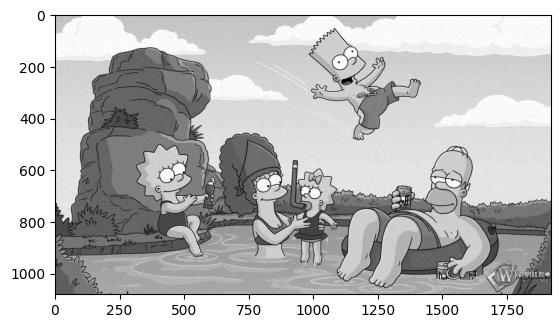

In [2]:
img1 = cv2.imread("../Imagenes_cursado/FAMILIA_a.jpg", cv2.IMREAD_GRAYSCALE)
plt.imshow(img1, cmap = "gray")

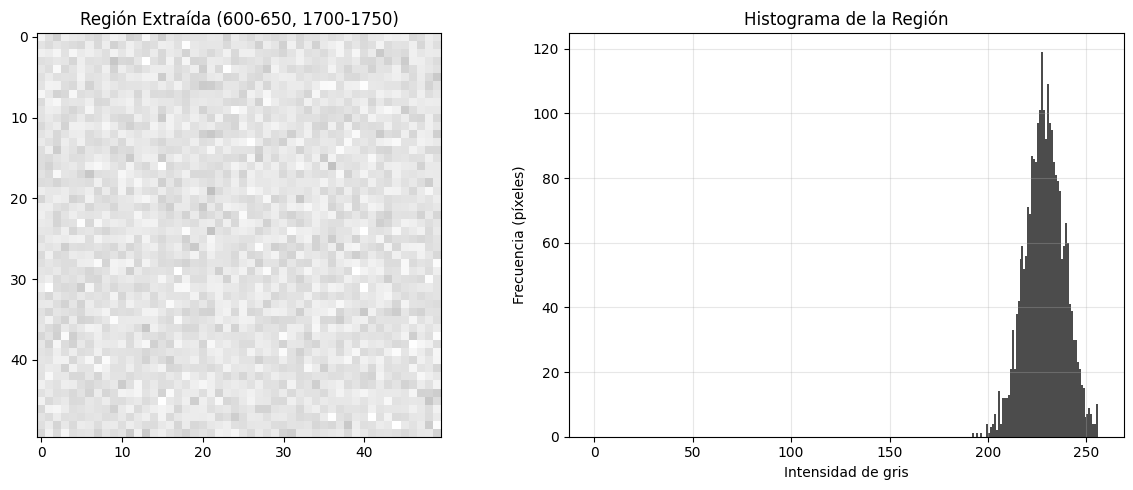

228.2044
9.913436368888439


In [5]:
# analizamos alguna zona homogenea como el cielo para ver como se distribuyen las intensidades
#renglones 600 a 650. columna de 1700 a 1750

roi = img1[600:650, 1700:1750]

plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.imshow(roi, cmap='gray', vmin=0, vmax=255)
plt.title('Región Extraída (600-650, 1700-1750)')
plt.axis('on') # Dejamos los ejes para verificar las coordenadas relativas


plt.subplot(1, 2, 2)
plt.hist(roi.ravel(), bins=256, range=(0, 256), color='black', alpha=0.7)
plt.title('Histograma de la Región')
plt.xlabel('Intensidad de gris')
plt.ylabel('Frecuencia (píxeles)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(np.mean(roi.ravel()))
print(np.std(roi.ravel()))

Se ve claramente un ruido normal. Para solucionar dicho ruido. Podemos utilizar un filtro de media aritmetica o geometrica. Probaremos este ultimo

In [6]:
def filtro_media_geometrica(image, kernel_size=3):
    img_f = image.astype(np.float64) + 1.0
    

    log_img = np.log(img_f)
    
    kernel = np.ones((kernel_size, kernel_size), np.float32) / (kernel_size**2)
    log_avg = cv2.filter2D(log_img, -1, kernel)

    geom_img = np.exp(log_avg) - 1.0
    
    return np.uint8(np.clip(geom_img, 0, 255))

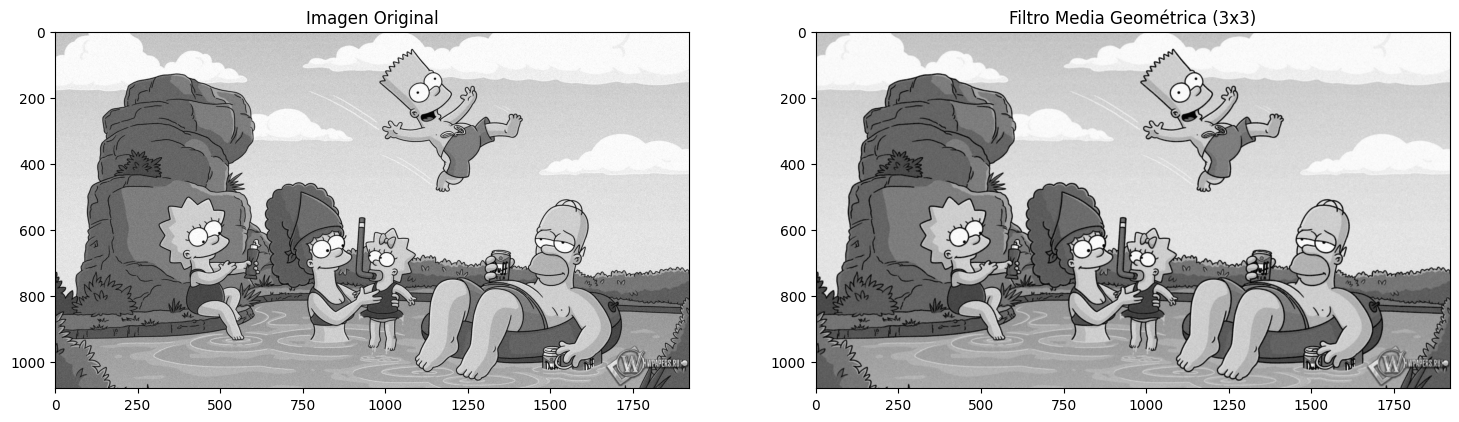

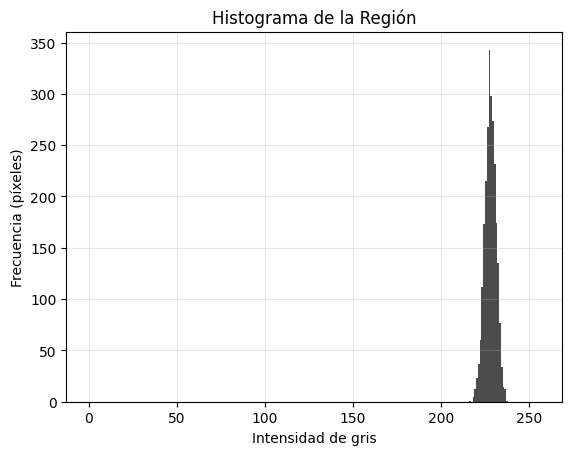

In [9]:
# 2. Aplicar el filtro
img_filtrada = filtro_media_geometrica(img1, kernel_size=3)

# 3. Visualización
plt.figure(figsize=(18, 10))
plt.subplot(1, 2, 1)
plt.imshow(img1, cmap='gray')
plt.title('Imagen Original')

plt.subplot(1, 2, 2)
plt.imshow(img_filtrada, cmap='gray')
plt.title('Filtro Media Geométrica (3x3)')
plt.show()

#analizamos roi
roi_f = img_filtrada[600:650, 1700:1750]

plt.hist(roi_f.ravel(), bins=256, range=(0, 256), color='black', alpha=0.7)
plt.title('Histograma de la Región')
plt.xlabel('Intensidad de gris')
plt.ylabel('Frecuencia (píxeles)')
plt.grid(True, alpha=0.3)

Vemos que hay menor desvio, es decir que es mas homogenea la zona, mejor

# ruido 2


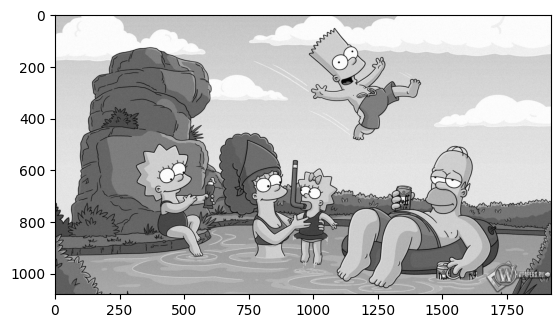

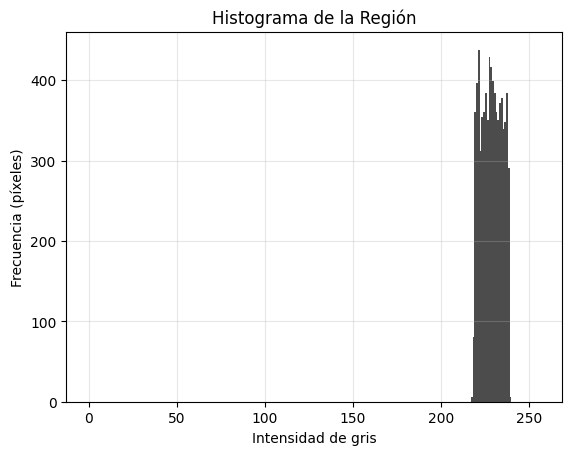

In [12]:
#mismo roi
img2 = cv2.imread("../Imagenes_cursado/FAMILIA_b.jpg")
plt.imshow(img2, cmap="gray")

plt.show()
roi_f = img2[600:650, 1700:1750]

plt.hist(roi_f.ravel(), bins=256, range=(0, 256), color='black', alpha=0.7)
plt.title('Histograma de la Región')
plt.xlabel('Intensidad de gris')
plt.ylabel('Frecuencia (píxeles)')
plt.grid(True, alpha=0.3)
plt.show()




Se aprecia que hay una especie de ruido uniforme. Tambien podria utilizar un filtro de media geometrica

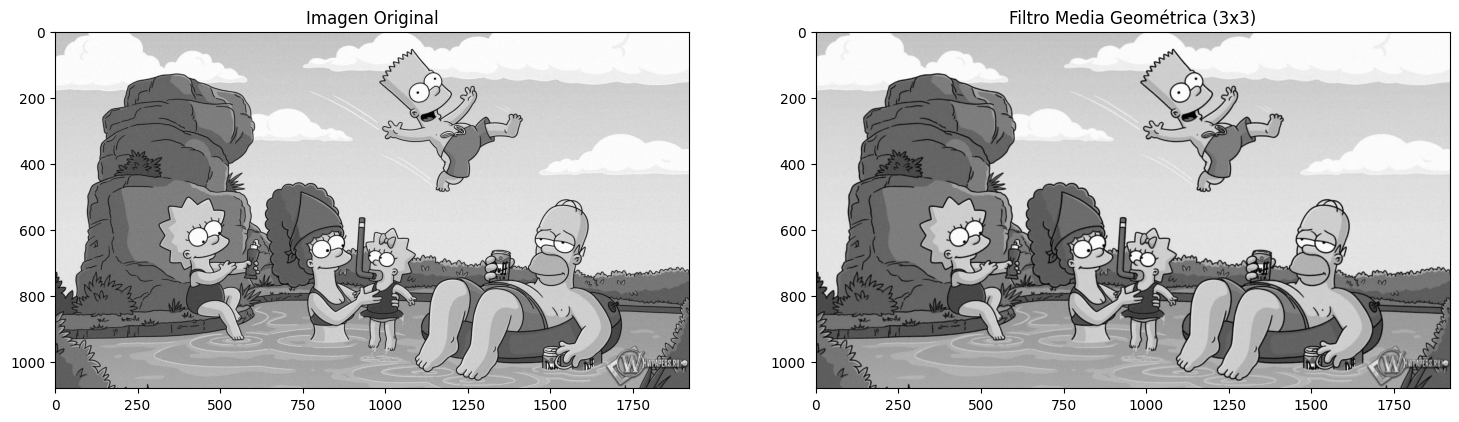

Text(0, 0.5, 'Frecuencia (píxeles)')

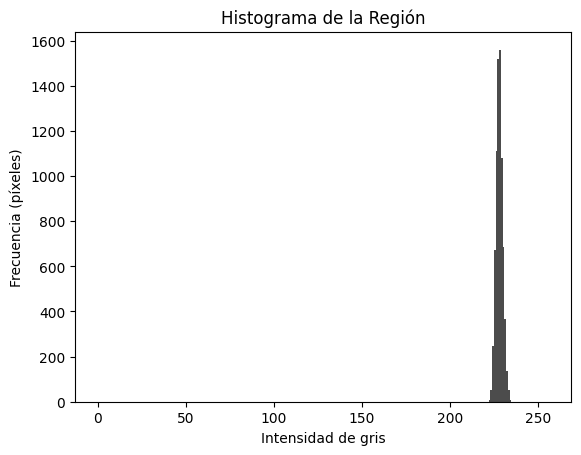

In [13]:
# 2. Aplicar el filtro
img_filtrada = filtro_media_geometrica(img2, kernel_size=3)

# 3. Visualización
plt.figure(figsize=(18, 10))
plt.subplot(1, 2, 1)
plt.imshow(img2, cmap='gray')
plt.title('Imagen Original')

plt.subplot(1, 2, 2)
plt.imshow(img_filtrada, cmap='gray')
plt.title('Filtro Media Geométrica (3x3)')
plt.show()

#analizamos roi
roi_f = img_filtrada[600:650, 1700:1750]

plt.hist(roi_f.ravel(), bins=256, range=(0, 256), color='black', alpha=0.7)
plt.title('Histograma de la Región')
plt.xlabel('Intensidad de gris')
plt.ylabel('Frecuencia (píxeles)')

# ejemplo 3

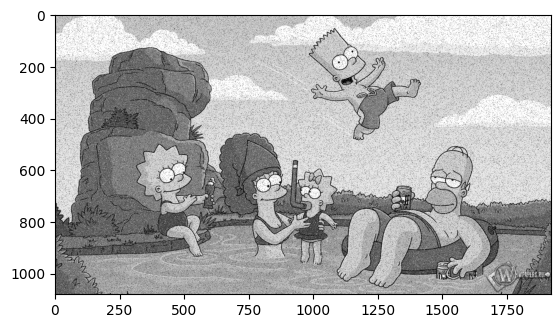

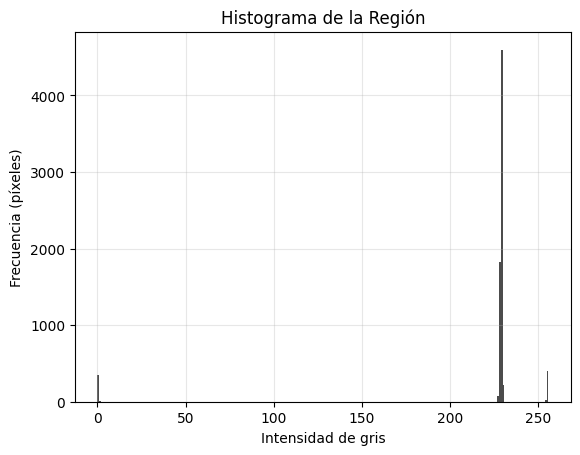

In [ ]:
#mismo roi
img2 = cv2.imread("../Imagenes_cursado/FAMILIA_c.jpg")
plt.imshow(img2, cmap="gray")
plt.show()
roi_f = img2[600:650, 1700:1750]

plt.hist(roi_f.ravel(), bins=256, range=(0, 256), color='black', alpha=0.7)
plt.title('Histograma de la Región')
plt.xlabel('Intensidad de gris')
plt.ylabel('Frecuencia (píxeles)')
plt.grid(True, alpha=0.3)
plt.show()

#sal y pimienta. Usamos filtro de mediana


Usaremos filtro de media mediana

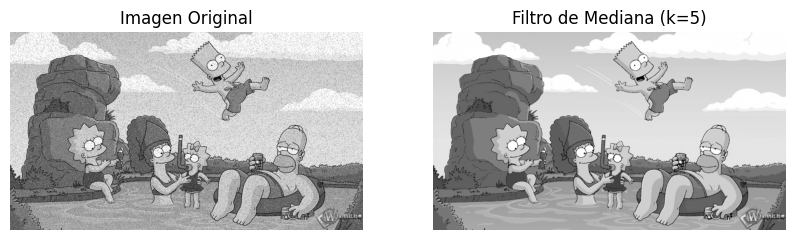

In [23]:
img_mediana = cv2.medianBlur(img2, 5)

# Visualización
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img2, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_mediana, cmap='gray')
plt.title('Filtro de Mediana (k=5)')
plt.axis('off')

plt.show()